In [23]:
import pandas as pd
df = pd.read_csv("loan_dataset.csv")
print(df.head())

   SNo  Age  Gender    Income     Employment  LoanAmount  LoanTerm  \
0    1   60    Male   59009.0     Unemployed       49199        48   
1    2   50    Male  113309.0      Full-time       13210        12   
2    3   36  Female   92046.0      Full-time       49363        60   
3    4   64    Male  136661.0      Part-time       17743        48   
4    5   29  Female   56143.0  Self-employed       47092        36   

   InterestRate  CreditScore   DTI  PastDefaults  NumLoans  Savings   EMI  \
0          5.88        846.0  0.56             2         2  42432.0  1961   
1         18.87        378.0  0.29             3         3  26108.0   563   
2         17.96        712.0  0.42             0         1   1493.0   259   
3          9.63        845.0  0.32             2         4  17465.0  1705   
4         18.63        468.0  0.32             0         2  40767.0  1473   

   Default  
0        1  
1        1  
2        1  
3        0  
4        1  


In [24]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SNo           1000 non-null   int64  
 1   Age           1000 non-null   int64  
 2   Gender        1000 non-null   str    
 3   Income        950 non-null    float64
 4   Employment    1000 non-null   str    
 5   LoanAmount    1000 non-null   int64  
 6   LoanTerm      1000 non-null   int64  
 7   InterestRate  1000 non-null   float64
 8   CreditScore   953 non-null    float64
 9   DTI           1000 non-null   float64
 10  PastDefaults  1000 non-null   int64  
 11  NumLoans      1000 non-null   int64  
 12  Savings       950 non-null    float64
 13  EMI           1000 non-null   int64  
 14  Default       1000 non-null   int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 117.3 KB
None
               SNo          Age         Income    LoanAmount     LoanTerm  \
count  1000.000000  1000.000000 

In [25]:
df = df.ffill()

In [26]:
df['Employment']=df['Employment'].str.replace('-','')
df['Employment']=df['Employment'].str.strip()

In [27]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Employment']=le.fit_transform(df['Employment'])

In [28]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['Employment']])

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['Age', 'Income', 'LoanAmount', 'LoanTerm',
                  'InterestRate', 'CreditScore', 'DTI',
                  'Savings', 'EMI']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_cols = ['Age', 'Income', 'LoanAmount', 'LoanTerm',
                  'InterestRate', 'CreditScore', 'DTI',
                  'Savings', 'EMI']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

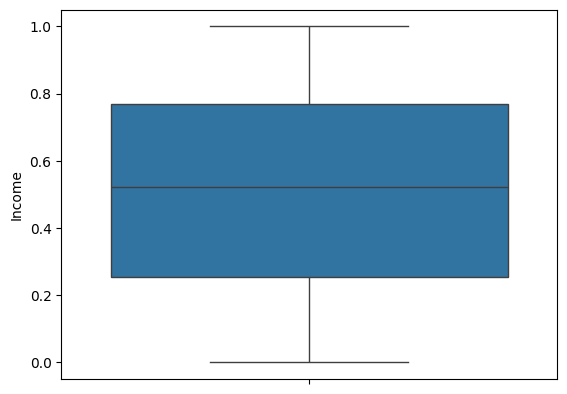

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df['Income'])
plt.show()

In [32]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Income'] >= Q1 - 1.5*IQR) & (df['Income'] <= Q3 + 1.5*IQR)]

In [35]:
num_cols = ['Age','Income','LoanAmount','LoanTerm','InterestRate',
            'CreditScore','DTI','PastDefaults','NumLoans','Savings','EMI']

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [36]:
df.to_csv("processed_dataset.csv",index=False)